In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as tfs
from torchvision.datasets import ImageFolder
import torch.utils.data as data

from PIL import Image

## Классная работа

### Трансформации изображения

In [ ]:
transforms = tfs.Compose([
    tfs.ToDtype(torch.uint8),
    # преобразования над пикселями изображения
    tfs.ToDtype(torch.float32, scale=True),
    # нормализация данных и изменение формы тензора
])

### Пользовательские трансформации

In [28]:
class Transf(nn.Module):
    def forward(self, item):
        # преобразование тензора item
        pass

### Пример трансформаций

In [29]:
class RavelTransform(nn.Module):
    def forward(self, item):
        return item.ravel()

In [34]:
transforms = tfs.Compose([
    tfs.ToDtype(torch.uint8),
    tfs.ToImage(), # переводит в тензор
    tfs.Grayscale(), # делает в оттенках серого (чтобы был 1 цветовой канал)
    tfs.ToDtype(torch.float32, scale=True), # изменяет тип данных (scale - чтобы диапазлон значений был от 0 до 1)
    tfs.Lambda(lambda img: img.ravel()), # вытягивает изображение в вектор
    RavelTransform() # по факту то же самое, что и предыдущая строка, только с использованием пользовательского класса
])

In [31]:
d_train = ImageFolder("/Users/sidorovegor/Desktop/projects/python/dl_selfedu_course/datasets/dataset_MNIST/train", transform=transforms)
train_data = data.DataLoader(d_train)

In [32]:
x, y = d_train[0]
x.shape, y

(torch.Size([784]), 0)

## Домашняя работа

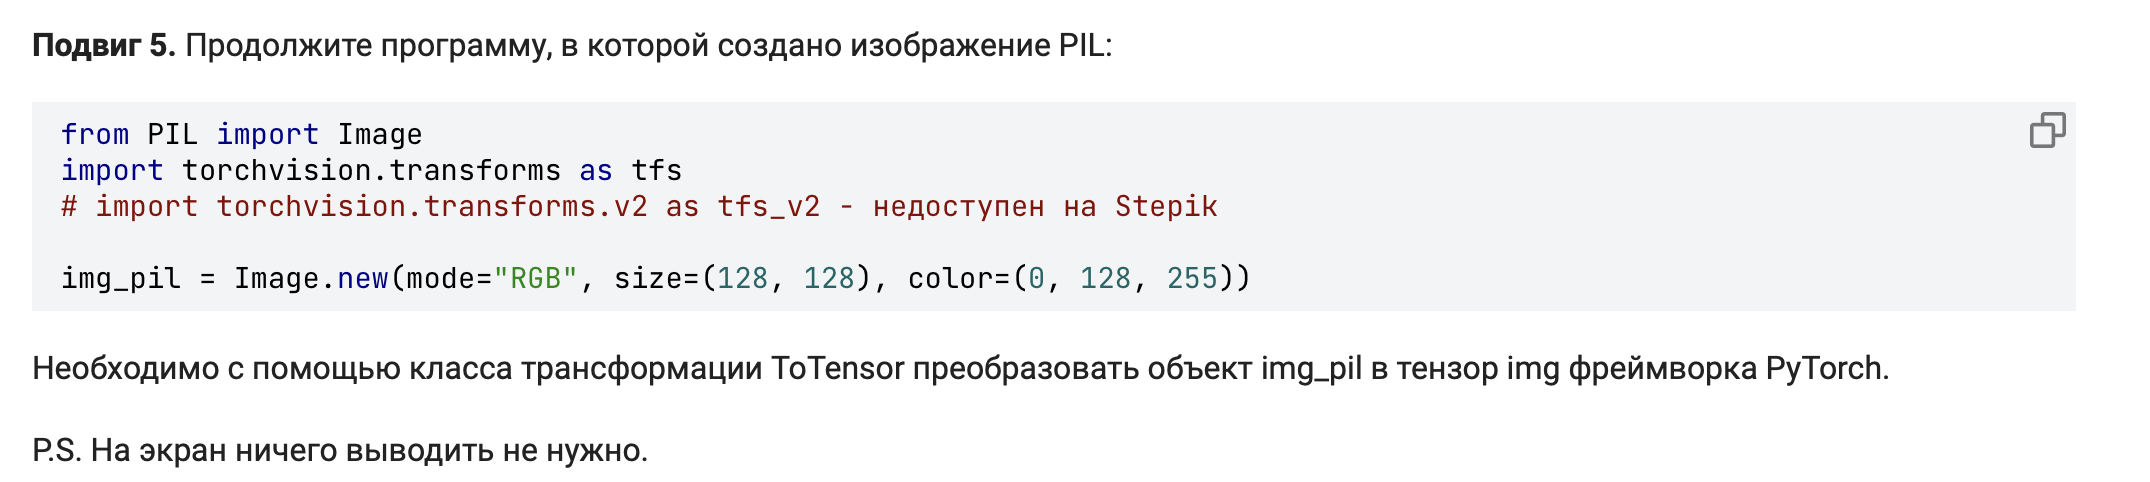

In [43]:
img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

# здесь продолжайте программу
img_pil = tfs.ToImage()(img_pil)

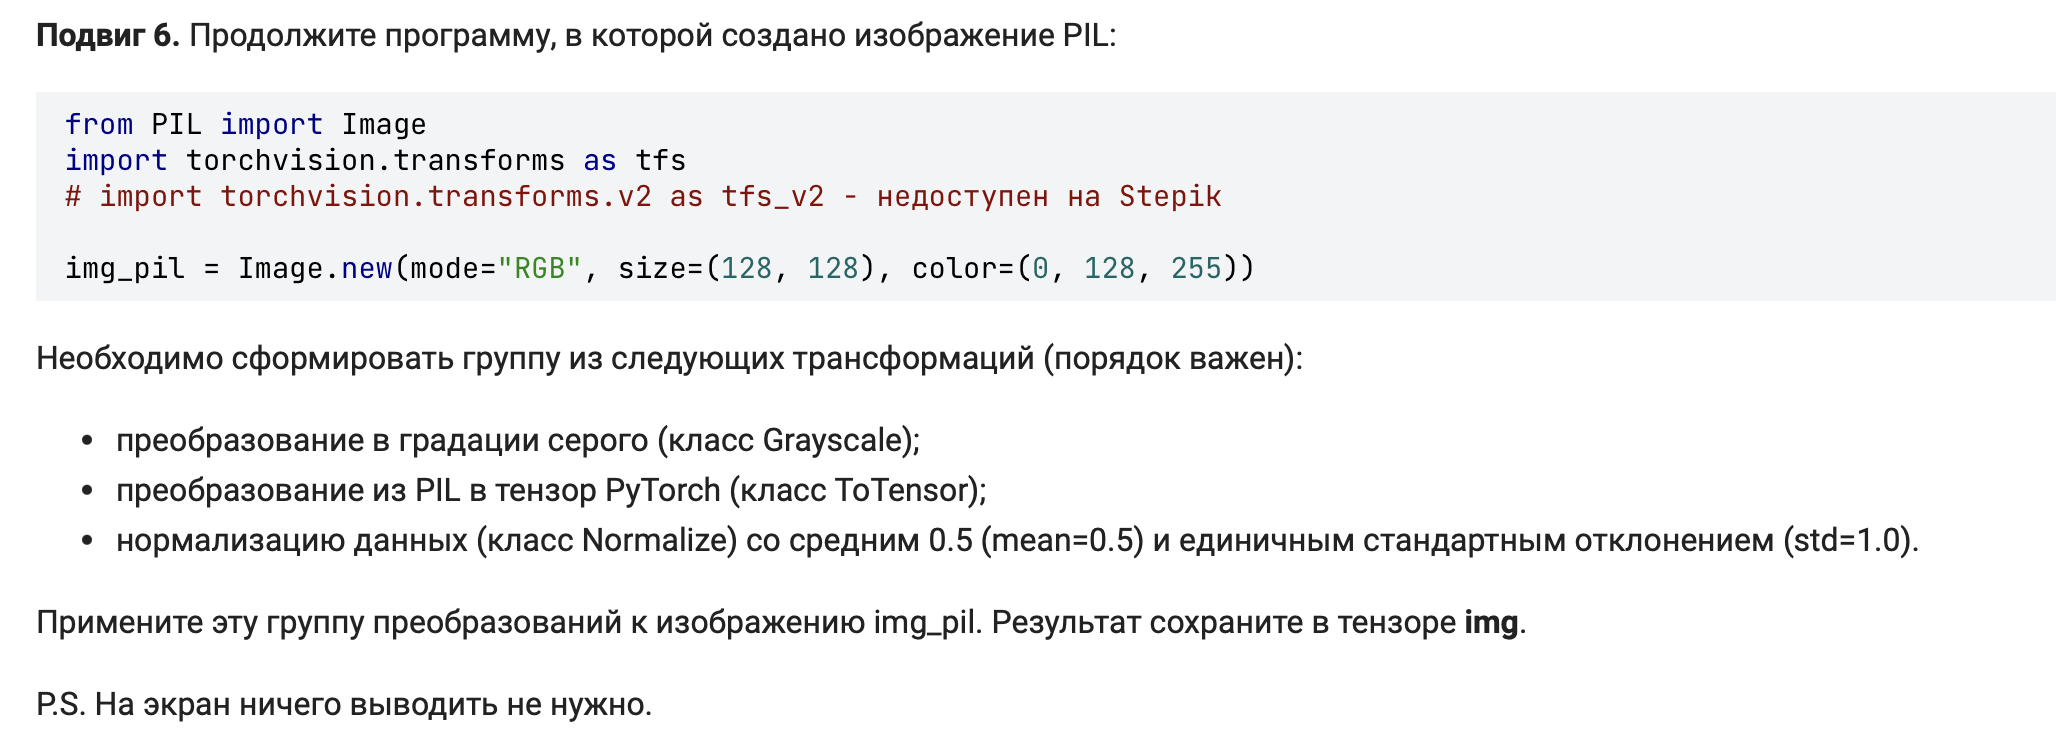

In [53]:
img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

transf = tfs.Compose([tfs.Grayscale(), tfs.ToTensor(), tfs.Normalize((0.5,), (1,))])
img = transf(img_pil)

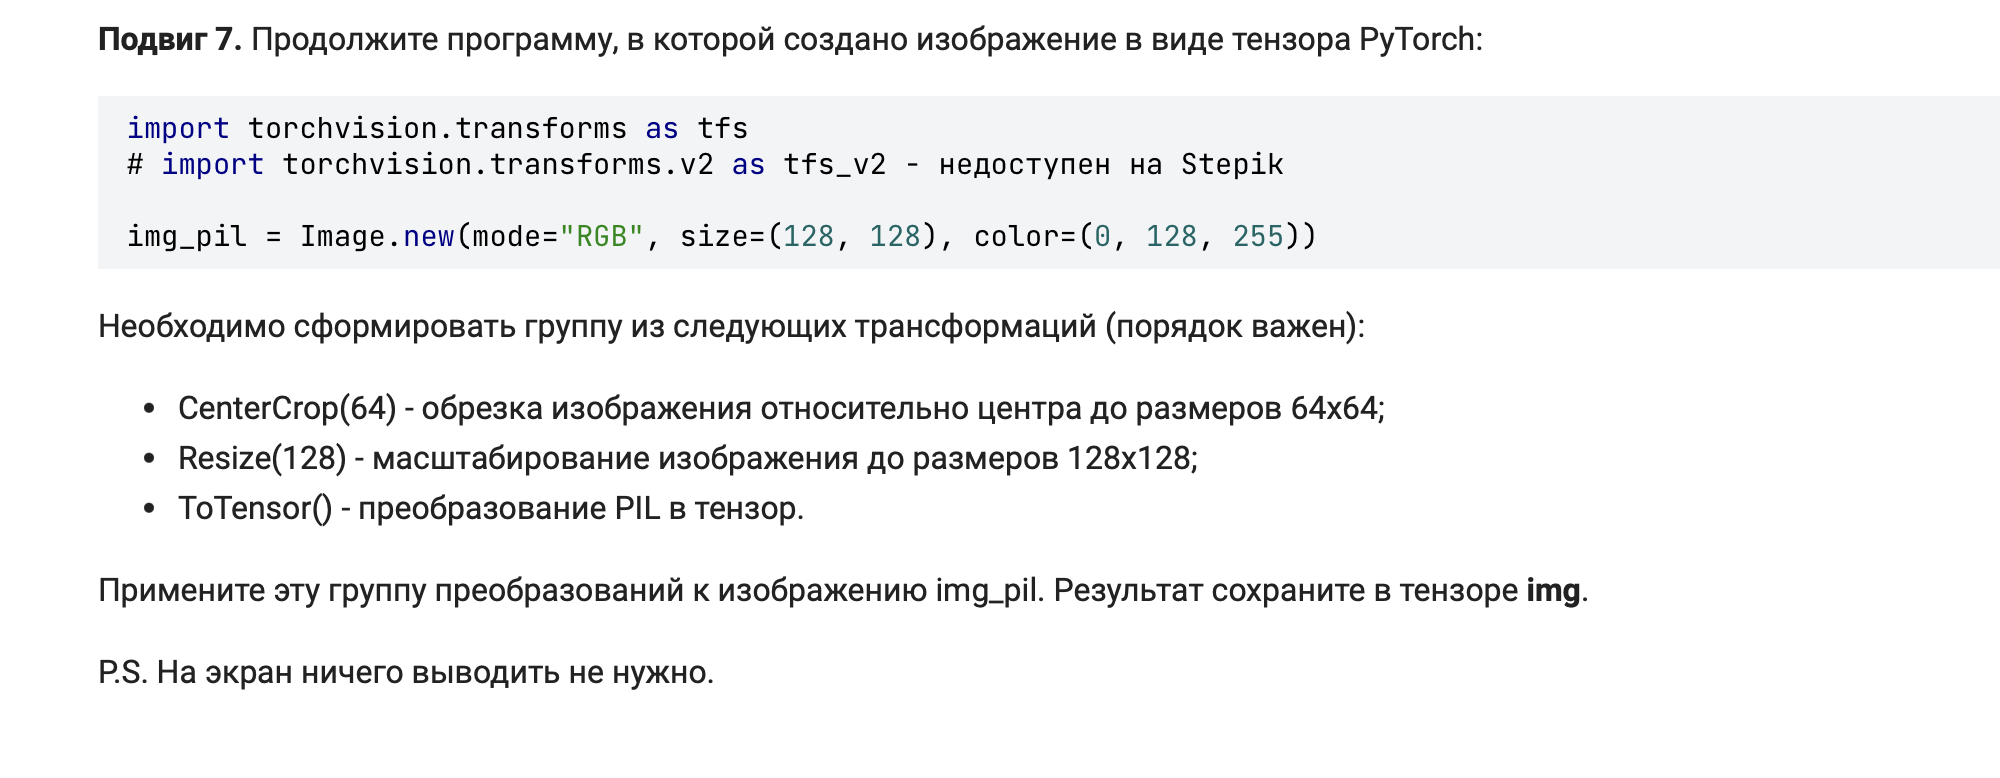

In [ ]:
img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

# здесь продолжайте программу
tr = tfs.Compose([tfs.CenterCrop(64), tfs.Resize(128), tfs.ToTensor()])
img = tr(img_pil)

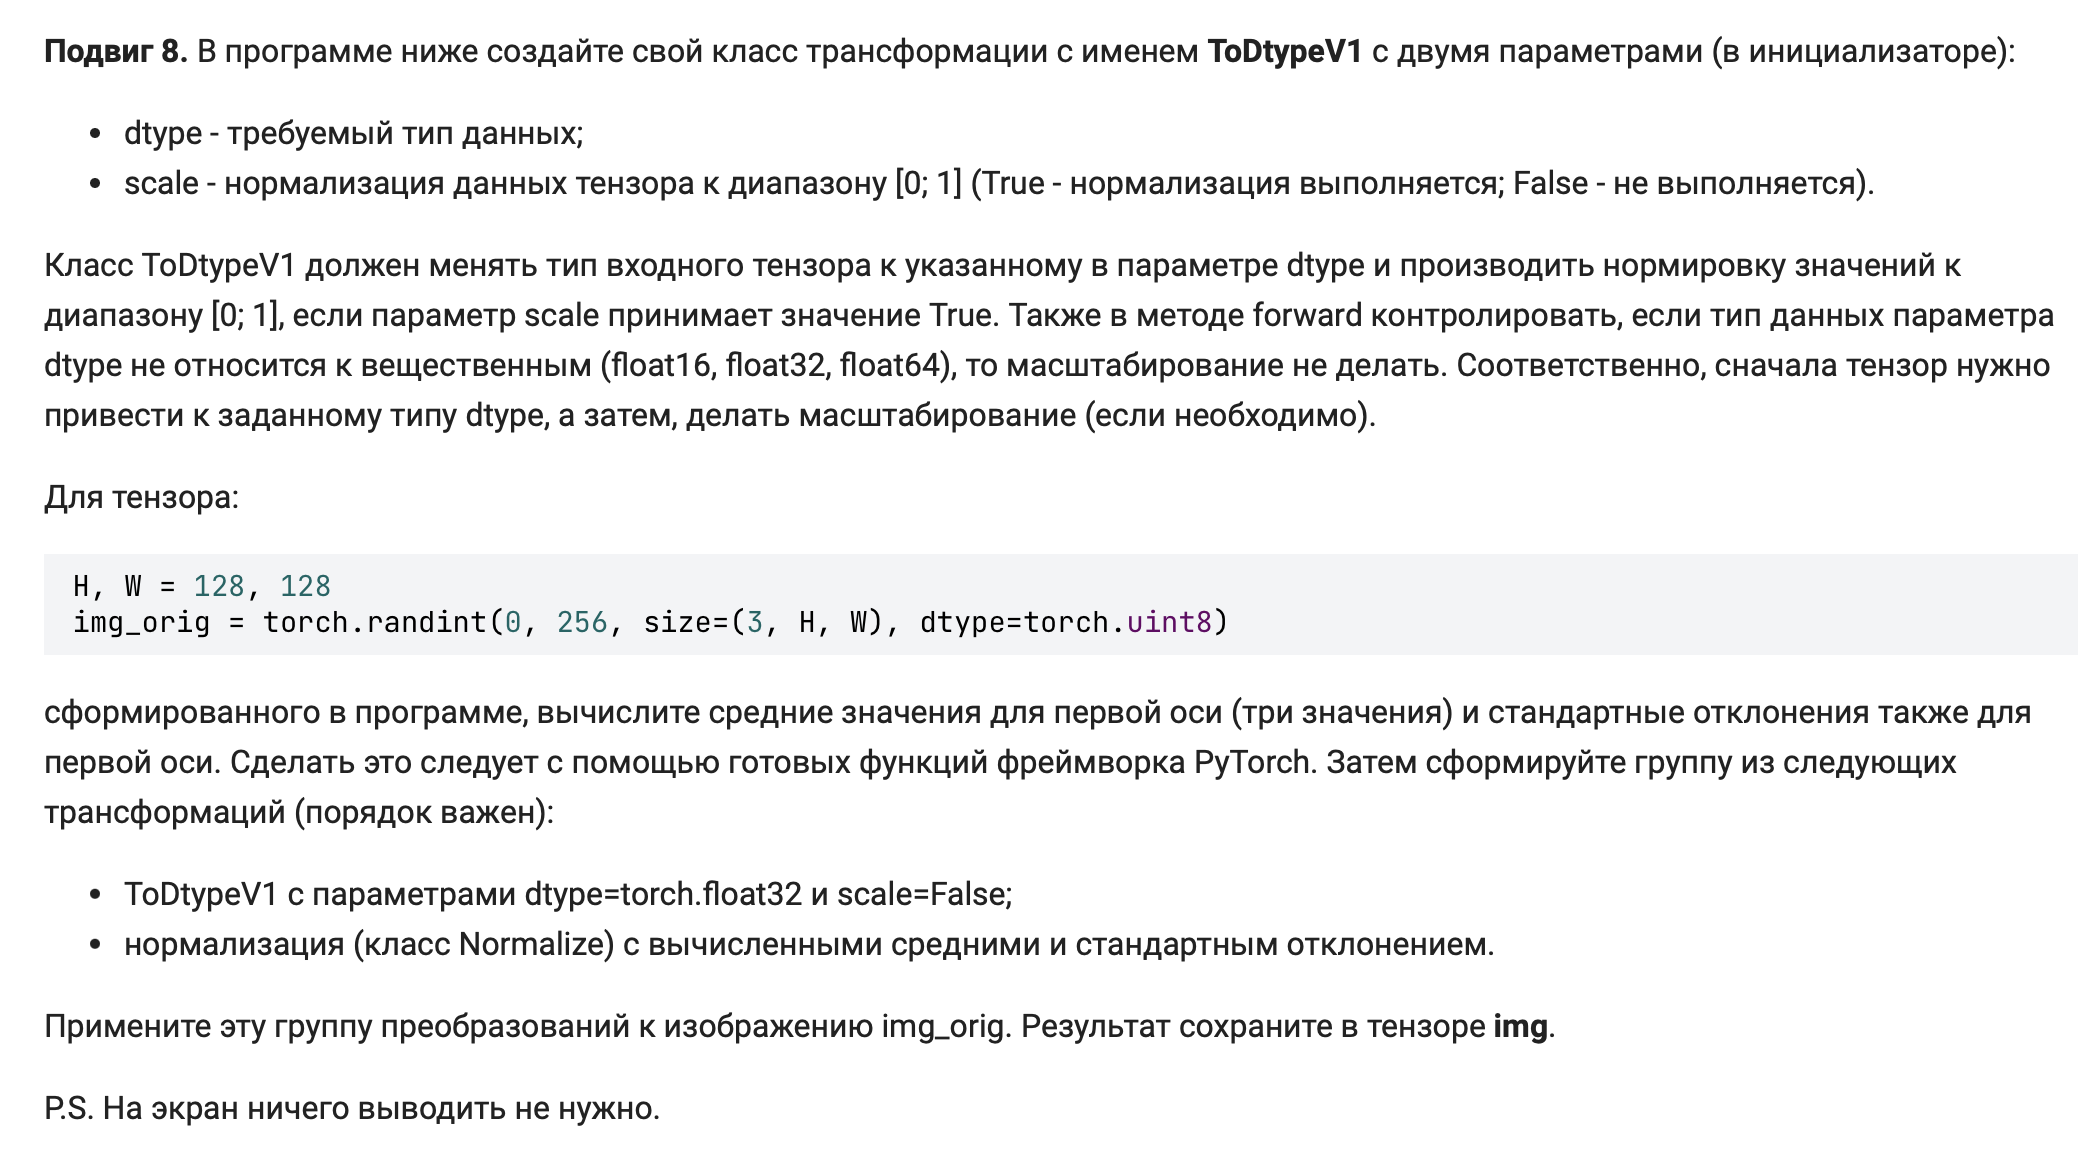

In [69]:
# здесь объявляйте класс ToDtypeV1
class ToDtypeV1(nn.Module):
    def __init__(self, dtype, scale):
        super().__init__()
        self.dtype = dtype
        self.scale = scale and (dtype in [torch.float16, torch.float32, torch.float64])

    def forward(self, x):
        x = x.to(dtype=self.dtype)
        if self.scale: x = (x - x.min()) / (x.max() - x.min())
        return x

H, W = 128, 128
img_orig = torch.randint(0, 256, size=(3, H, W), dtype=torch.uint8) # тензор в программе не менять

img_mean = img_orig.float().mean(dim=(1, 2)) # средние для каждого цветового канала (первая ось)
img_std = img_orig.float().std(dim=(1, 2)) # стандартное отклонение для каждого цветового канала (первая ось)

# здесь продолжайте программу
tf = tfs.Compose([ToDtypeV1(torch.float32, False), tfs.Normalize(img_mean, img_std)])
img = tf(img_orig)

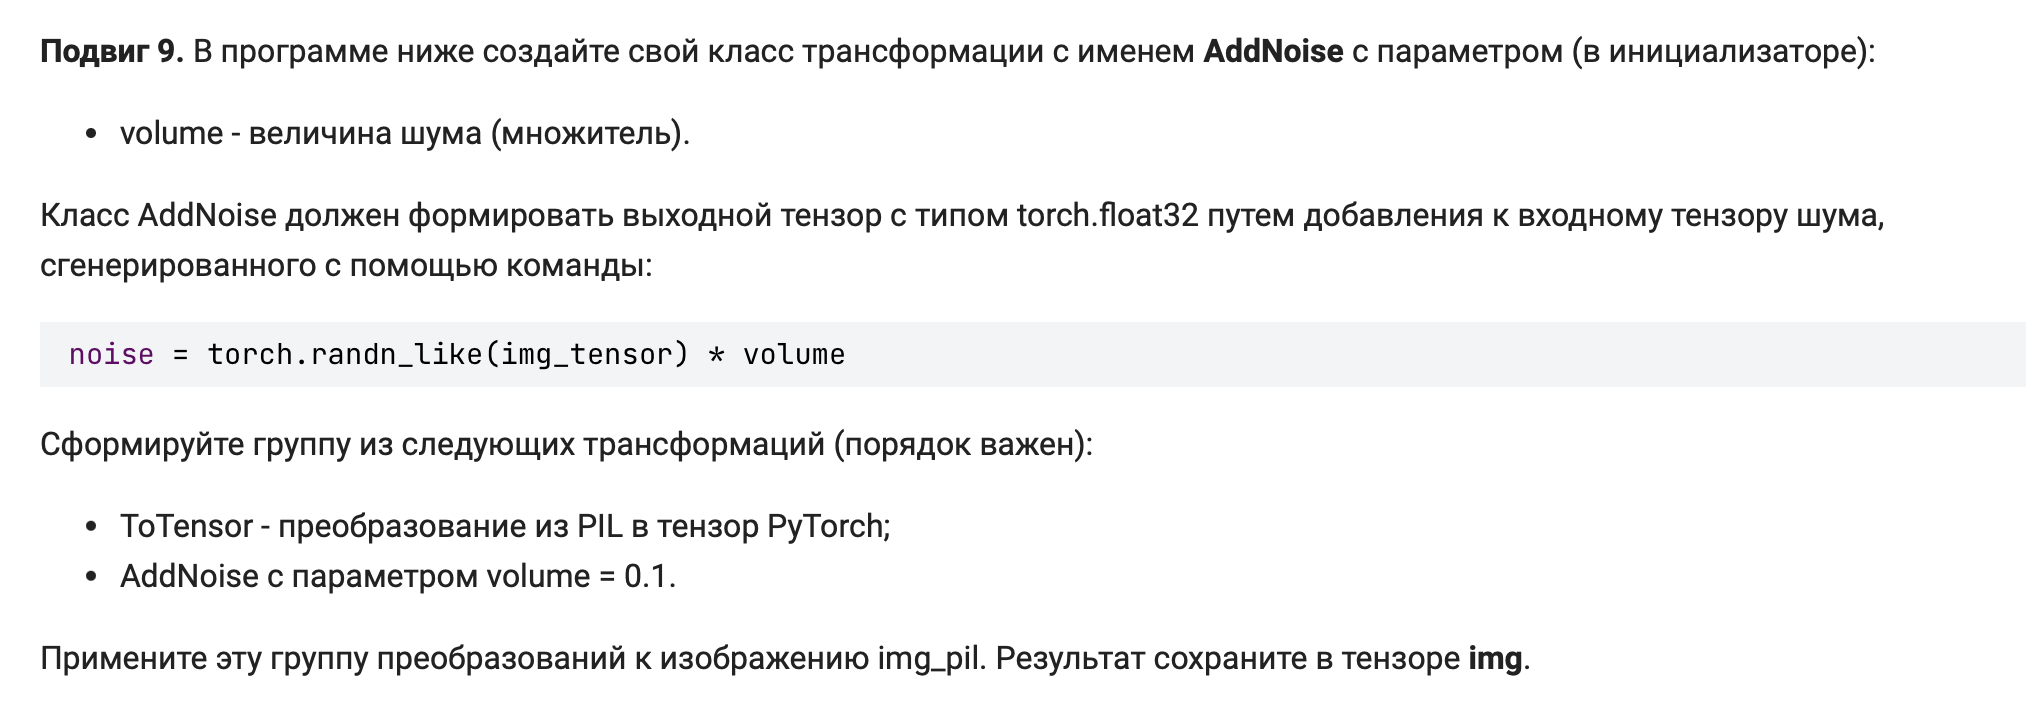

In [73]:
# здесь объявляйте класс AddNoise
class AddNoise(nn.Module):
    def __init__(self, volume):
        super().__init__()
        self.volume = volume

    def forward(self, item):
        noise = torch.randn_like(item) * self.volume
        return item + noise

img_pil = Image.new(mode="RGB", size=(128, 128), color=(0, 128, 255))

# здесь продолжайте программу
tr = tfs.Compose([tfs.ToTensor(), AddNoise(0.1)])
img = tr(img_pil)

/Users/sidorovegor/Desktop/projects/python/dl_selfedu_course/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
